This small script show a counterexample for the hyperbolicity of the extended Gramian closure for odd $M$ from:
https://doi.org/10.48550/arXiv.2407.05894

The paper proposed:
$$
\sigma_{n-1,n+1} \sigma_{n-1,n-1} = \chi \sigma_{n-1,n}^2
$$
with $\chi = \frac{n+1}{2n}$.
From this, the closure for $M=3$ follows with:
$$
u_4 = \frac{u_3 u_1}{u_0} + \chi \frac{\left( u_3 - \frac{u_2 u_1}{u_0} \right)^2}{u_2 - \frac{u_1 u_1}{u_0}}
$$

In the following, the characteristic polynomial (see the paper) is calculated symbolically, certain (realizable moments) are inserted and the roots of the characteristic polynomial are calculated.
These roots show imaginary value, resulting in non hyperbolicity.

In [1]:
# imports
import numpy as np
import pandas as pd
from scipy.integrate import quad

from sympy import *
u0, u1, u2, u3, u4 = symbols('u0 u1 u2 u3 u4')
c = symbols('c')
init_printing(use_unicode=True)

In [2]:
# Define size of system
M=3
n=int((M+1)/2)
chi = (n+1)/(2*n)

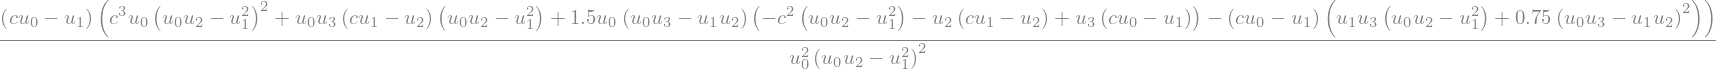

In [3]:
# Substitutes for the characteristic polynomial
sigma11 = u2 - u1 * u1 / u0
sigma12 = u3 - u2 * u1 / u0
# Closure
u4 = u3 * u1 / u0 + chi * (u3 - (u2*u1)/u0)**2 / (u2 - u1*u1/u0)

# Characteristic polynomial
P_expr = (
    c**1 - Matrix(Matrix([1]).T * Matrix([u0]).inv() * Matrix([u1]))[0]     # p_{n-1}(c)
) * (
    (
        c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_tilde_{n+1}
    ) - 2 * chi * sigma12 / sigma11 * (
        c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]  # p_n(c)
    )
)
P = simplify(P_expr)
P

In [4]:
# Bimodal distribution
def fbimodal(rho1_bimodal, v1_bimodal, theta1_bimodal, rho2_bimodal, v2_bimodal, theta2_bimodal, c):
    term1 = (rho1_bimodal / np.sqrt(2 * np.pi * theta1_bimodal)) * np.exp(-(c - v1_bimodal) ** 2 / (2 * theta1_bimodal))
    term2 = (rho2_bimodal / np.sqrt(2 * np.pi * theta2_bimodal)) * np.exp(-(c - v2_bimodal) ** 2 / (2 * theta2_bimodal))
    return term1 + term2

# --- fixed parameters ---
rho1_bimodal = 40 / 100
v1_bimodal = 0
theta1_bimodal = 100 / 100
rho2_bimodal = 60 / 100
theta2_bimodal = 10 / 10

# underlying distribution with fixed parameters
def fhid(c, v2):
    return fbimodal(rho1_bimodal, v1_bimodal, theta1_bimodal, rho2_bimodal, v2, theta2_bimodal, c)

# moments 
def uhid(v2, Mmax):
    """Compute first Mmax+2 raw moments (0..Mmax+1)."""
    moments = []
    for k in range(Mmax + 2):
        integrand = lambda c: (c ** k) * fhid(c, v2)
        val, _ = quad(integrand, -np.inf, np.inf)
        moments.append(val)
    return np.array(moments)

def momList(M, v2):
    """Return first M+1 moments."""
    return uhid(v2, M)[:M+1]

In [5]:
# Generate moments
v2 = 2.0
moments = momList(M, v2)
print(f'Moments to be inserted: {moments}')

Moments to be inserted: [1.  1.2 3.4 8.4]


In [6]:
# Substitute moments into characteristic polynomial
subs_dict_equilibrium = {
    u0: moments[0],
    u1: moments[1],
    u2: moments[2],
    u3: moments[3]
}

P_subs = simplify(P.subs(subs_dict_equilibrium))

# Calculate roots
roots = solve(Eq(P_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
print(f'Roots: {roots_subs}')

Roots: [1.20000000000005, 1.67988059712182, 0.813120925928943 - 0.500423929485926*I, 0.813120925928943 + 0.500423929485926*I]
